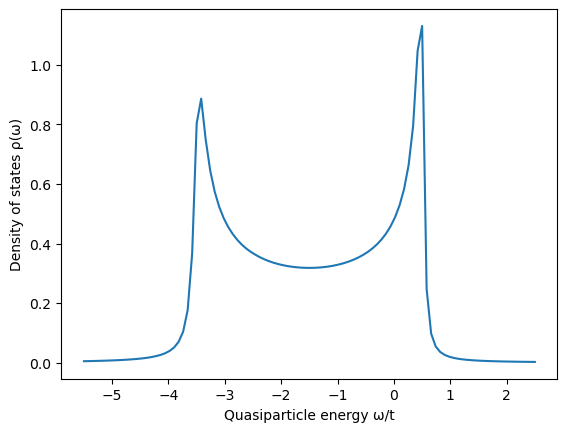

In [9]:
# Standard imports in every numerical Python code
import numpy as np
import matplotlib.pyplot as plt

# Bodge is designed to be imported in this way, but you can
# of course `import bodge as bdg` if you really want to
from bodge import *

# Define the tight-binding model parameters
Lx = 512
Ly = 1
Lz = 1

t = 1
μ = 1.5 * t

# Construct the Hamiltonian
lattice = CubicLattice((Lx, Ly, Lz))
system = Hamiltonian(lattice)

with system as (H, _):
    for i in lattice.sites():
        H[i, i] = -μ * σ0
    for i, j in lattice.bonds():
        H[i, j] = -t * σ0

# If you need the Hamiltonian matrix itself, you could use:
# H = system.matrix()  # NumPy dense array
# H = system.matrix(format="csr")  # SciPy sparse matrix

# Calculate the central density of states
i = (Lx//2, Ly//2, Lz//2)
ω = np.linspace(-μ-4*t, -μ+4*t, 101)
ρ = system.ldos(i, ω)

# Plot the density of states at the system center
plt.figure()
plt.xlabel("Quasiparticle energy ω/t")
plt.ylabel("Density of states ρ(ω)")
plt.plot(ω, ρ)

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from bodge import *

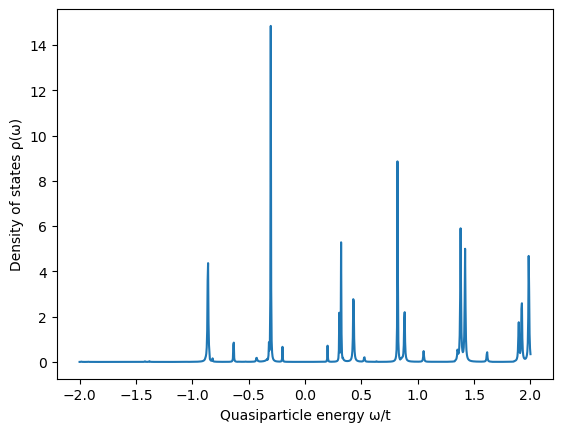

In [17]:
# Model parameters
Lx = 10
Ly = 10

t = 1
μ = -3 * t
Δs = 0.2 * t

# Construct the Hamiltonian
lattice = CubicLattice((Lx, Ly, 1))
system = Hamiltonian(lattice)

with system as (H, Δ):
    for i in lattice.sites():
        H[i, i] = -μ * σ0
        Δ[i, i] = -Δs * jσ2
    for i, j in lattice.bonds():
        H[i, j] = -t * σ0

# Calculate the density of states
i = (Lx//2, Ly//2, 0)
ω = np.linspace(-10 * Δs, 10 * Δs, 1001)
ρ = system.ldos(i, ω)

# Plot the results
plt.figure()
plt.xlabel("Quasiparticle energy ω/t")
plt.ylabel("Density of states ρ(ω)")
plt.plot(ω, ρ)

In [ ]:

# Model parameters
Lx = 100
Ly = 100

t = 1
μ = -3 * t
Δs = 0.2 * t

# Construct the Hamiltonian
lattice = CubicLattice((Lx, Ly, 1))
system = Hamiltonian(lattice)

with system as (H, Δ):
    for i in lattice.sites():
        Δi = Δs * np.exp(2*π*1j*i[0]/Lx)
        H[i, i] = -μ * σ0
        Δ[i, i] = -Δi * jσ2
    for i, j in lattice.bonds():
        H[i, j] = -t * σ0
    for i, j in lattice.edges():
        H[i, j] = -t * σ0

# Calculate the density of states
i = (Lx//2, Ly//2, 0)
ω = np.linspace(-1.5 * Δs, 1.5 * Δs, 101)
ρ = system.ldos(i, ω)

# Plot the results
plt.figure()
plt.xlabel("Quasiparticle energy ω/t")
plt.ylabel("Density of states ρ(ω)")
plt.plot(ω, ρ)